# Семинар 08 - Нейросети

In [1]:
!pip install torchvision


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
# warnings.simplefilter('ignore')
import torch
from torch.utils.data import DataLoader, Dataset, Subset
import torchvision
from torchvision import transforms
from matplotlib import pyplot as plt
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split
import torch
print(torch.__version__)

2.9.0


<a id="Content"></a>
# Содержание
0. [Вспомним PyTorch](#0)
1. [Подготовка данных](#1)
2. [Определим архитектуру нейросети в PyTorch](#2)
3. [Что мы можем улучшить?](#3)
   - [Нормировка](#3.1)
   - [Функции активации](#3.2)
   - [Инициализация весов](#3.3)
   - [Влияние метода оптимизации градиентного спуска](#3.4)
   - [Влияние скорости обучения](#3.5)
4. [Полезные ссылки](#4)

<a id="0"></a>
# 0. Вспомним PyTorch

Нахождение сложной производной

Найдите производную по x от функции
$$\sin\left(\tan(x)\frac{x^2}{y} + \ln(e^{-x^2 + 3}+x^3y)\right)\tan(x^2e^{x^9})$$

При этом надо пользоваться встроенным в PyTorch autograd. Численное вычисление производной может не дать нужный результат.

In [3]:
def find_x_derivative(x, y):
    x_with_grad = torch.tensor([float(x)], requires_grad=True)
    y_with_grad = torch.tensor([float(y)], requires_grad=True)

    z = torch.sin(torch.tan(x_with_grad)*(x_with_grad**2/y_with_grad) + torch.log(torch.exp(-x_with_grad**2+3) + y_with_grad*x_with_grad**3))*torch.tan(torch.exp(x_with_grad**9)*x_with_grad**2)
    z.backward()

    dz_dx = x_with_grad.grad
    return dz_dx.item(), z

In [4]:
find_x_derivative(1,21)

(-9.020709991455078, tensor([0.1239], grad_fn=<MulBackward0>))

<a id="1"></a>
# 1. Подготовка данных

### В семинаре, будем использовать набор данных `fashion_mnist`, загрузим их

In [5]:
from torchvision import datasets, transforms

In [6]:
trainset = datasets.FashionMNIST('~/.pytorch/F_MNIST_data/', train = True, download=True)

In [7]:
testset = datasets.FashionMNIST('~/.pytorch/F_MNIST_data/', train = False, download = True)

In [8]:
num_classes = len(trainset.classes)

In [9]:
trainset.classes

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [10]:
x_train = trainset.data
y_train = trainset.targets

x_test = testset.data
y_test = testset.targets

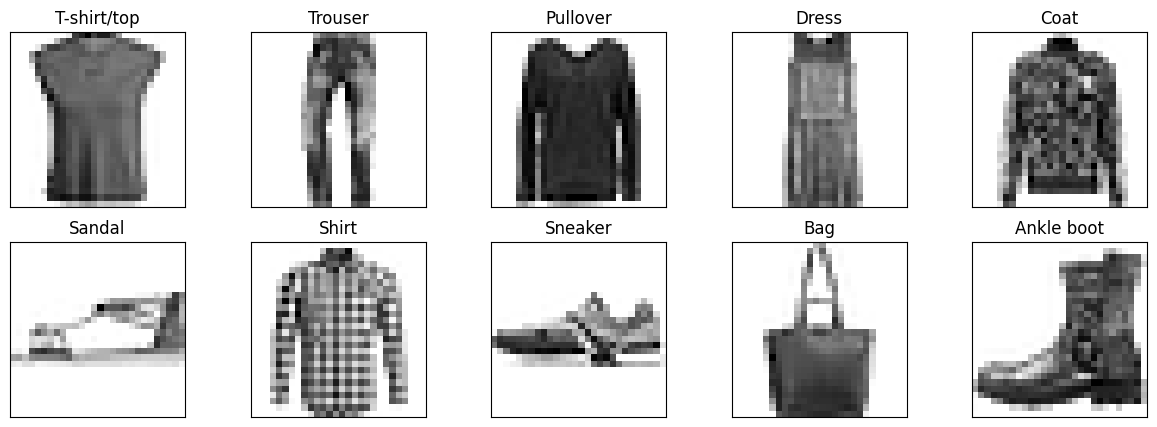

In [11]:
fig = plt.figure(figsize=(15,5))
for i in range(num_classes):
    ax = fig.add_subplot(2, 5, 1 + i, xticks=[], yticks=[])
    idx = np.where(y_train[:]==i)[0]
    features_idx = x_train[idx,::]
    img_num = np.random.randint(features_idx.shape[0])
    im = features_idx[img_num]
    ax.set_title(trainset.classes[i])
    plt.imshow(im, cmap='gray_r')
plt.show()

### Проведем небольшие предобработки

In [12]:
x_train_flat = x_train.flatten(start_dim=1).float()
x_test_flat = x_test.flatten(start_dim=1).float()
print(f'Была размерность: {x_train.shape}, стала: {x_train_flat.shape}')
print(f'Была размерность: {x_test.shape}, стала: {x_test_flat.shape}')

Была размерность: torch.Size([60000, 28, 28]), стала: torch.Size([60000, 784])
Была размерность: torch.Size([10000, 28, 28]), стала: torch.Size([10000, 784])


In [13]:
D_out = num_classes
D_in = x_train_flat.shape[1]

<a id="2"></a>
# 2. Определим архитектуру нейросети в PyTorch

Вариантов определения архитектуры много, рассмотрим 2 наиболее популярных варианта

In [62]:
model = torch.nn.Sequential(
    torch.nn.Linear(D_in, 128),
    torch.nn.Sigmoid(),
    torch.nn.Linear(128, 10),
    torch.nn.Sigmoid(),
    torch.nn.Linear(10, D_out),
    torch.nn.Softmax(dim=1)
)

In [63]:
import torch.nn.functional as F

class Model(torch.nn.Module):
    def __init__(self):
        super(Model, self).__init__()
        self.fc1 = torch.nn.Linear(D_in, 128)
        self.act1 = torch.nn.Sigmoid()
        self.fc2 = torch.nn.Linear(128, 10)
        self.act2 = torch.nn.Sigmoid()
        self.fc3 = torch.nn.Linear(10, D_out)
        self.act3 = torch.nn.Softmax(dim=1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act1(x)
        x = self.fc2(x)
        x = self.act2(x)
        x = self.fc3(x)
        x = self.act3(x)
        return x

model = Model()

In [64]:
model

Model(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (act1): Sigmoid()
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (act2): Sigmoid()
  (fc3): Linear(in_features=10, out_features=10, bias=True)
  (act3): Softmax(dim=1)
)

In [65]:
x_train_flat.shape

torch.Size([60000, 784])

In [66]:
# Forward pass: compute predicted y by passing x to the model. Module objects
# override the __call__ operator so you can call them like functions. When
# doing so you pass a Tensor of input data to the Module and it produces
# a Tensor of output data.
y_pred = model(x_train_flat)

In [67]:
y_pred.shape

torch.Size([60000, 10])

In [68]:
loss_fn = torch.nn.CrossEntropyLoss()

In [69]:
# Compute and print loss. We pass Tensors containing the predicted and true
# values of y, and the loss function returns a Tensor containing the
# loss.
loss_old = loss_fn(y_pred, y_train)
loss_old

tensor(2.3030, grad_fn=<NllLossBackward0>)

In [70]:
acc_old = accuracy_score(y_train.numpy(), y_pred.argmax(dim=1))
acc_old

0.09968333333333333

In [71]:
# Zero the gradients before running the backward pass.
model.zero_grad()

In [72]:
# Backward pass: compute gradient of the loss with respect to all the learnable
# parameters of the model. Internally, the parameters of each Module are stored
# in Tensors with requires_grad=True, so this call will compute gradients for
# all learnable parameters in the model.
loss_old.backward()

In [73]:
learning_rate = 1e-2

**Задание 0:** Обновите веса, используя градиентный спуск. 

*Hint:* Каждый параметр - это тензор из PyTorch, так что градиенты можно получить так же, как мы это делали в начале семинара. Параметры для обновления хранятся в model.parameters()

In [ ]:
# Update the weights using gradient descent. Each parameter is a Tensor, so
# we can access its gradients like we did before.
with torch.no_grad():
    # YOUR CODE HERE

In [75]:
y_pred = model(x_train_flat.float())
loss_new = loss_fn(y_pred, y_train)
step = loss_new.item()-loss_old.item()

acc_new = accuracy_score(y_train, y_pred.argmax(dim=1))

print(f'Лосс: {loss_old.item()} -> {loss_new.item()}. Step {step} ')
print(f'Accuracy: {acc_old} -> {acc_new}')

Лосс: 2.302971363067627 -> 2.3029561042785645. Step -1.52587890625e-05 
Accuracy: 0.09968333333333333 -> 0.09978333333333333


**Задание 1:** Реализуйте обучение модели на одном батче.

In [ ]:
def batch_train(model, loss_fn, learning_rate, x, y):
    # YOUR CODE HERE

    # return(loss.item())

In [77]:
def train(model, n_epochs, batch_size, learning_rate,  X, y, X_test, y_test):
    acc_train_all = []
    loss_train_all = []
    acc_test_all = []
    loss_test_all = []

    for epoch in range(n_epochs):

        permutation = torch.randperm(X.size()[0])

        for i in tqdm(range(0,X.float().size()[0], batch_size)):
            indices = permutation[i:i+batch_size]
            batch_x, batch_y = X[indices], y[indices]
            batch_train(model, loss_fn, learning_rate, batch_x, batch_y)

        y_test_pred = model(X_test)
        y_train_pred = model(X)


        acc_train = accuracy_score(y, y_train_pred.argmax(dim=1))
        loss_train = loss_fn(y_train_pred, y).detach()
        acc_test = accuracy_score(y_test, y_test_pred.argmax(dim=1))
        loss_test = loss_fn(y_test_pred, y_test).detach()

        acc_train_all = np.append(acc_train_all, acc_train)
        loss_train_all = np.append(loss_train_all, loss_train)
        acc_test_all = np.append(acc_test_all, acc_test)
        loss_test_all = np.append(loss_test_all, loss_test)


        print(f'Epoch {epoch}: \n Accuracy - train: {acc_train} | test: {acc_test} \n Loss - train: {loss_train} | test: {loss_test}')

    return(acc_train_all, loss_train_all, acc_test_all, loss_test_all)

In [78]:
n_epochs = 10
batch_size = 1000
learning_rate = 1
model = Model()
acc_train_all, loss_train_all, acc_test_all, loss_test_all = \
          train(model, n_epochs, batch_size, learning_rate, x_train_flat, y_train, x_test_flat, y_test)


100%|██████████| 60/60 [00:00<00:00, 607.04it/s]


Epoch 0: 
 Accuracy - train: 0.2670666666666667 | test: 0.267 
 Loss - train: 2.2328414916992188 | test: 2.232879161834717


100%|██████████| 60/60 [00:00<00:00, 549.27it/s]


Epoch 1: 
 Accuracy - train: 0.45881666666666665 | test: 0.4595 
 Loss - train: 2.127614736557007 | test: 2.1282761096954346


100%|██████████| 60/60 [00:00<00:00, 604.18it/s]


...

Epoch 7: 
 Accuracy - train: 0.5472833333333333 | test: 0.5443 
 Loss - train: 1.96366286277771 | test: 1.9655958414077759


100%|██████████| 60/60 [00:00<00:00, 698.94it/s]


Epoch 8: 
 Accuracy - train: 0.5617833333333333 | test: 0.5601 
 Loss - train: 1.9437099695205688 | test: 1.945854902267456


100%|██████████| 60/60 [00:00<00:00, 694.97it/s]


Epoch 9: 
 Accuracy - train: 0.5646666666666667 | test: 0.5601 
 Loss - train: 1.922023057937622 | test: 1.9246795177459717


In [79]:
def vis_history(acc_train_all, loss_train_all, acc_test_all, loss_test_all):
    fig = plt.figure(figsize=(16, 4))

    plt.subplot(1, 2, 1)

    plt.plot(loss_train_all, label='loss')
    plt.plot(loss_test_all, label='val_loss')

    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(acc_train_all, label='acc')
    plt.plot(acc_test_all, label='val_acc')

    plt.legend()
    plt.show()

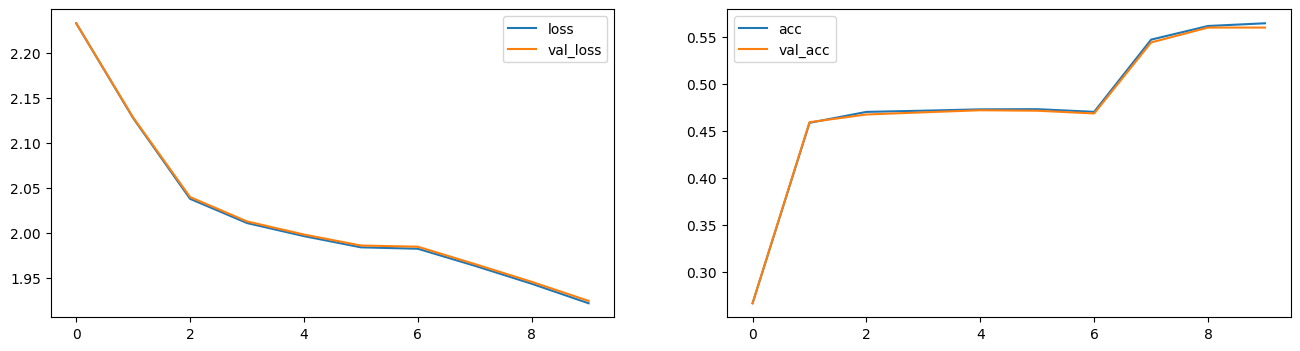

In [80]:
vis_history(acc_train_all, loss_train_all, acc_test_all, loss_test_all)

<a id="3"></a>
# 3. Что мы можем улучшить?
- Отнормировать признаки
- Задать правила инициации весов
- Выбрать функцию активации
- Настроить скорость обучения

<a id="3.1"></a>
## 3.1. Нормировка
![picture](img/normalize.png)

![img](img/batch_norm.png)

In [81]:
import torch.nn.functional as F

class ModelNorm(torch.nn.Module):
    def __init__(self):
        super(ModelNorm, self).__init__()
        self.act1 = torch.nn.Sigmoid()
        self.fc1 = torch.nn.Linear(D_in, 128)
        self.bn1 = torch.nn.BatchNorm1d(128)
        self.fc2 = torch.nn.Linear(128, 10)
        self.bn2 = torch.nn.BatchNorm1d(10)
        self.fc3 = torch.nn.Linear(10, D_out)
        self.act2 = torch.nn.Softmax(dim=1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.act1(x)
        x = self.fc2(x)
        x = self.bn2(x)
        x = self.act1(x)
        x = self.fc3(x)
        x = self.act2(x)
        return x

model_norm = ModelNorm()

In [82]:
mean = x_train_flat.mean()
std = x_train_flat.std()

x_train_norm = (x_train_flat - mean) / std
x_test_norm = (x_test_flat - mean) / std

In [83]:
x_train_norm.max(), x_train_norm.min()

(tensor(2.0224), tensor(-0.8103))

In [84]:
n_epochs = 10
batch_size = 1000
learning_rate = 1
acc_train_all, loss_train_all, acc_test_all, loss_test_all = train(model_norm, n_epochs, batch_size, learning_rate,
                                                                   x_train_norm, y_train, x_test_norm, y_test)


100%|██████████| 60/60 [00:00<00:00, 441.55it/s]


Epoch 0: 
 Accuracy - train: 0.3363833333333333 | test: 0.3369 
 Loss - train: 2.2080862522125244 | test: 2.2085671424865723


100%|██████████| 60/60 [00:00<00:00, 464.90it/s]


Epoch 1: 
 Accuracy - train: 0.4432333333333333 | test: 0.443 
 Loss - train: 2.0973317623138428 | test: 2.097942352294922


100%|██████████| 60/60 [00:00<00:00, 449.65it/s]


...

Epoch 7: 
 Accuracy - train: 0.6665666666666666 | test: 0.66 
 Loss - train: 1.8301011323928833 | test: 1.8342357873916626


100%|██████████| 60/60 [00:00<00:00, 429.75it/s]


Epoch 8: 
 Accuracy - train: 0.6952 | test: 0.6872 
 Loss - train: 1.8034549951553345 | test: 1.809308409690857


100%|██████████| 60/60 [00:00<00:00, 419.86it/s]

Epoch 9: 
 Accuracy - train: 0.7026333333333333 | test: 0.6934 
 Loss - train: 1.7862699031829834 | test: 1.7940753698349


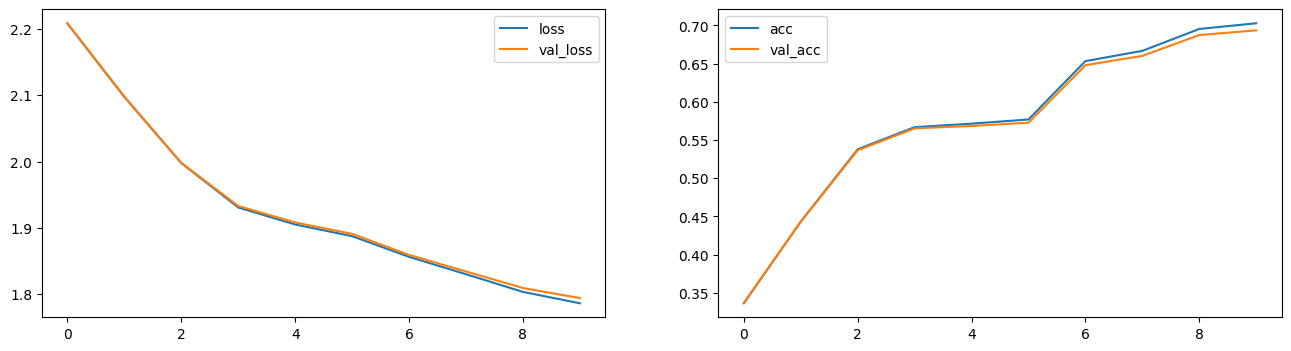

In [85]:
vis_history(acc_train_all, loss_train_all, acc_test_all, loss_test_all)

<a id="3.2"></a>
## 3.2. Функции активации
![picture](img/activations.png)

In [86]:
class ModelReLU(torch.nn.Module):
    def __init__(self):
        super(ModelReLU, self).__init__()
        self.act1 = torch.nn.ReLU()
        self.fc1 = torch.nn.Linear(D_in, 128)
        self.bn1 = torch.nn.BatchNorm1d(128)
        self.fc2 = torch.nn.Linear(128, 10)
        self.bn2 = torch.nn.BatchNorm1d(10)
        self.fc3 = torch.nn.Linear(10, D_out)
        self.act2 = torch.nn.Softmax(dim=1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.act1(x)
        x = self.fc2(x)
        x = self.bn2(x)
        x = self.act1(x)
        x = self.fc3(x)
        x = self.act2(x)
        return x

model_relu = ModelReLU()

In [87]:
n_epochs = 10
batch_size = 1000
learning_rate = 1

acc_train_all, loss_train_all, acc_test_all, loss_test_all = train(model_relu, n_epochs, batch_size, learning_rate, x_train_norm, y_train, x_test_norm, y_test)


100%|██████████| 60/60 [00:00<00:00, 341.98it/s]


Epoch 0: 
 Accuracy - train: 0.6365166666666666 | test: 0.6315 
 Loss - train: 1.824944257736206 | test: 1.8296722173690796


100%|██████████| 60/60 [00:00<00:00, 390.38it/s]


Epoch 1: 
 Accuracy - train: 0.7315 | test: 0.7218 
 Loss - train: 1.749397873878479 | test: 1.7559492588043213


100%|██████████| 60/60 [00:00<00:00, 442.66it/s]


...

Epoch 7: 
 Accuracy - train: 0.8906166666666666 | test: 0.8651 
 Loss - train: 1.5763142108917236 | test: 1.6003679037094116


100%|██████████| 60/60 [00:00<00:00, 414.73it/s]


Epoch 8: 
 Accuracy - train: 0.8982 | test: 0.867 
 Loss - train: 1.5685936212539673 | test: 1.5966646671295166


100%|██████████| 60/60 [00:00<00:00, 397.63it/s]


Epoch 9: 
 Accuracy - train: 0.8951833333333333 | test: 0.8644 
 Loss - train: 1.5719274282455444 | test: 1.6008143424987793


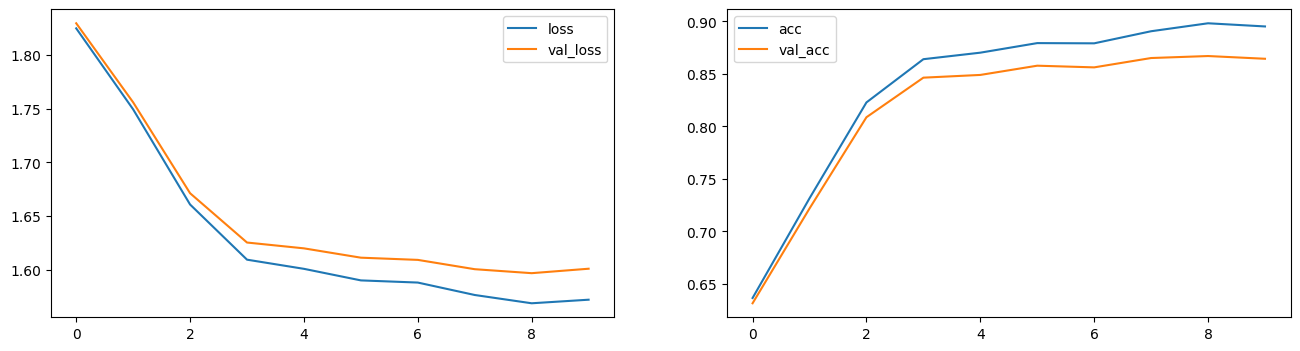

In [88]:
vis_history(acc_train_all, loss_train_all, acc_test_all, loss_test_all)

<a id="3.3"></a>
## 3.3. Инициализация весов

__Случайно__  
$ w = a * N(0, 1)$, но тогда если $a \gg 1$, то на выходе $b\gg1$ и если $a \ll 1 $, то $b \approx 0 $  

$ D(w^T*x) = n*D(w)*D(x) $ar(x)

__Xavier__  
$a = \frac{1}{\sqrt{n}}$, где $n$ - кол-во нейронов на входе

__He__  
$a = \frac{1}{\sqrt{\frac{n}{2}}}$, где $n$ - кол-во нейронов на входе

In [89]:
def init_weights(m):
    if type(m) == torch.nn.Linear:
        torch.nn.init.kaiming_normal_(m.weight)
        m.bias.data.fill_(0.01)

Применим к модели  функцию инициации весов с помощью метода .apply()

In [90]:
model_relu = ModelReLU()

In [91]:
model_he = model_relu.apply(init_weights)

In [92]:
n_epochs = 10
batch_size = 1000
learning_rate = 1

acc_train_all, loss_train_all, acc_test_all, loss_test_all = train(model_he, n_epochs, batch_size, learning_rate,
                                                                   x_train_norm, y_train, x_test_norm, y_test)


100%|██████████| 60/60 [00:00<00:00, 455.64it/s]


Epoch 0: 
 Accuracy - train: 0.7682 | test: 0.7607 
 Loss - train: 1.7208385467529297 | test: 1.7277841567993164


100%|██████████| 60/60 [00:00<00:00, 453.32it/s]


Epoch 1: 
 Accuracy - train: 0.7927333333333333 | test: 0.7814 
 Loss - train: 1.6772410869598389 | test: 1.686769962310791


100%|██████████| 60/60 [00:00<00:00, 452.11it/s]


...

Epoch 7: 
 Accuracy - train: 0.894 | test: 0.8642 
 Loss - train: 1.5729039907455444 | test: 1.5999751091003418


100%|██████████| 60/60 [00:00<00:00, 467.46it/s]


Epoch 8: 
 Accuracy - train: 0.8921666666666667 | test: 0.8655 
 Loss - train: 1.5744948387145996 | test: 1.6012729406356812


100%|██████████| 60/60 [00:00<00:00, 456.78it/s]


Epoch 9: 
 Accuracy - train: 0.9011 | test: 0.8686 
 Loss - train: 1.564857006072998 | test: 1.5954965353012085


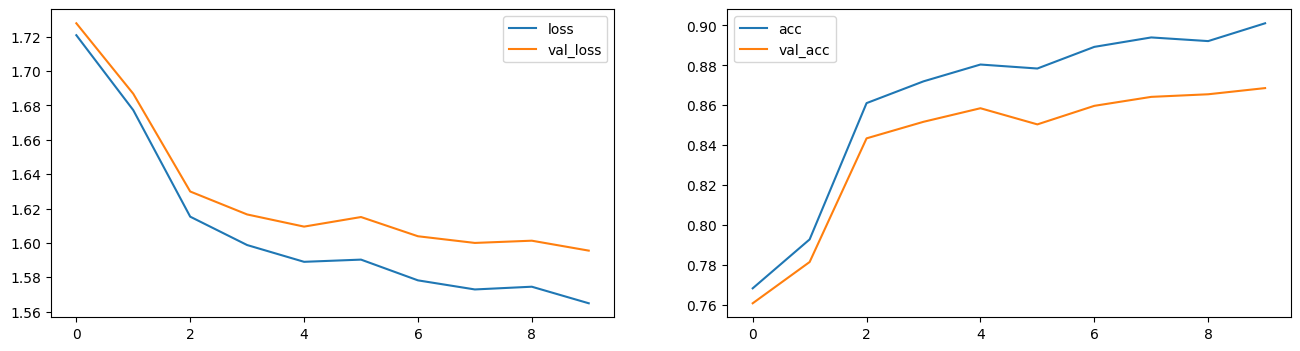

In [93]:
vis_history(acc_train_all, loss_train_all, acc_test_all, loss_test_all)

<a id="3.4"></a>
## 3.4. Влияние метода оптимизации градиентного спуска

![picture](img/optimizers7.gif)

**Momentum**

![img](img/momentum_formula.png)

Вместо того, чтобы использовать только градиент текущего шага, мы будем накапливать импульс градиента прошлых шагов для определения направления движения.
![img](img/momentum.jpg)

В связи со стохастической природой, обновления градиента происходят "зигзагообразно", с помощью момента мы усиливаем движение вдоль основного направления. На практике коэффициент у момента инициализируется на уровне 0,5 и постепенно увеличивается до 0,9 в течение нескольких эпох.
![img](img/sgd_momentum.jpg)
  
**RMSProp** (Root Mean Square Propogation)

Покомпонентно накапливаем квадрат векторов градиентов и используем в качестве нормировки. Коэффициент $\beta$ отвечает за то, что нам важнее сохранить, предыдущие градиенты или новые.

![image](img/rmsprop.png)

**Adam** (Adaptive momentum)

Используем и накопленный импульс, и накопленный квадрат градиентов

![image](img/adam.png)новления весов для типичных признаков

### Update batch train

In [94]:
def batch_train(model, optimizer, x, y):
    y_pred = model(x)
    loss = loss_fn(y_pred, y)
    model.zero_grad()
    loss.backward()
    optimizer.step()
    return (loss.item())

### Prepare models

In [95]:
model_relu = ModelReLU()
model_he_SGD = model_relu.apply(init_weights)

In [96]:
model_relu = ModelReLU()
model_he_Momentum = model_relu.apply(init_weights)

In [97]:
model_relu = ModelReLU()
model_he_Adam = model_relu.apply(init_weights)

### Prepare optimizers

In [98]:
optimizerSGD = torch.optim.SGD(model_he_SGD.parameters(), lr=0.01, momentum=0.0)

In [99]:
optimizerMomentum = torch.optim.SGD(model_he_Momentum.parameters(), lr=0.01, momentum=0.9)

In [100]:
optimizerAdam = torch.optim.Adam(model_he_Adam.parameters(), lr=0.01)

### Train

In [101]:
n_epochs = 10
batch_size = 1000


loss_test_sgd = []
loss_test_sgd_moment = []
loss_test_adam = []

for epoch in range(n_epochs):

    permutation = torch.randperm(x_train_norm.size()[0])

    for i in tqdm(range(0,x_train_norm.float().size()[0], batch_size)):
        indices = permutation[i:i+batch_size]
        batch_x, batch_y = x_train_norm[indices], y_train[indices]
        batch_train(model_he_SGD, optimizerSGD, batch_x, batch_y)
        batch_train(model_he_Momentum, optimizerMomentum, batch_x, batch_y)
        batch_train(model_he_Adam, optimizerAdam, batch_x, batch_y)

    y_test_pred = model_he_SGD(x_test_norm)
    loss_train = loss_fn(y_test_pred, y_test).detach().numpy()
    print(f' SGD Epoch: {epoch} loss {loss_train}')
    loss_test_sgd.append(loss_train)

    y_test_pred = model_he_Momentum(x_test_norm)
    loss_train = loss_fn(y_test_pred, y_test).detach().numpy()
    print(f' Momentum Epoch: {epoch} loss {loss_train}')
    loss_test_sgd_moment.append(loss_train)

    y_test_pred = model_he_Adam(x_test_norm)
    loss_train = loss_fn(y_test_pred, y_test).detach().numpy()
    print(f' Adam Epoch: {epoch} loss {loss_train}')
    loss_test_adam.append(loss_train)

100%|██████████| 60/60 [00:00<00:00, 154.29it/s]


 SGD Epoch: 0 loss 2.20443058013916
 Momentum Epoch: 0 loss 2.094524621963501
 Adam Epoch: 0 loss 1.689725399017334


100%|██████████| 60/60 [00:00<00:00, 155.52it/s]


 SGD Epoch: 1 loss 2.1607322692871094
 Momentum Epoch: 1 loss 1.9970571994781494
 Adam Epoch: 1 loss 1.6158255338668823


100%|██████████| 60/60 [00:00<00:00, 143.00it/s]


...

 SGD Epoch: 7 loss 2.051917314529419
 Momentum Epoch: 7 loss 1.6954553127288818
 Adam Epoch: 7 loss 1.5936115980148315


100%|██████████| 60/60 [00:00<00:00, 140.00it/s]


 SGD Epoch: 8 loss 2.0418825149536133
 Momentum Epoch: 8 loss 1.6827157735824585
 Adam Epoch: 8 loss 1.591964602470398


100%|██████████| 60/60 [00:00<00:00, 153.38it/s]

 SGD Epoch: 9 loss 2.033029794692993
 Momentum Epoch: 9 loss 1.6725521087646484
 Adam Epoch: 9 loss 1.587823748588562


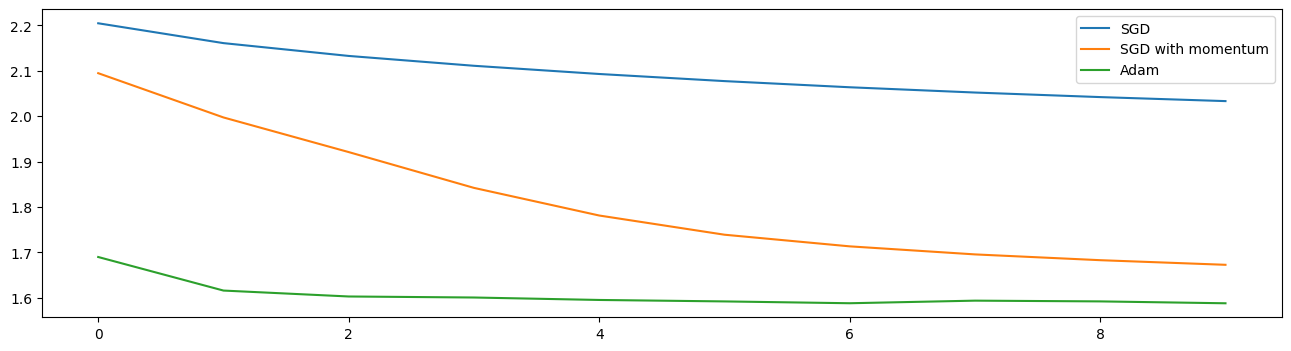

In [102]:
fig = plt.figure(figsize=(16, 4))

plt.plot(loss_test_sgd, label='SGD')
plt.plot(loss_test_sgd_moment, label='SGD with momentum')
plt.plot(loss_test_adam, label='Adam')

plt.legend()
plt.show()

<a id="3.5"></a>
## 3.5. Влияние скорости обучения
Посмотрим, как влияет параметр `learning_rate` на качество нашей модели на обучающей выборке

In [103]:
model_relu = ModelReLU()
model_he_Adam = model_relu.apply(init_weights)

In [104]:
optimizerAdam = torch.optim.Adam(model_he_Adam.parameters(), lr=0.01)

In [105]:
import torch.optim.lr_scheduler as lr_scheduler

scheduler = lr_scheduler.LinearLR(optimizerAdam, start_factor=1.0, end_factor=0.01, total_iters=10)

In [106]:
def train(model, optimizer, scheduler, n_epochs, batch_size,  X, y, X_test, y_test):
    acc_train_all = []
    loss_train_all = []
    acc_test_all = []
    loss_test_all = []

    for epoch in range(n_epochs):

        permutation = torch.randperm(X.size()[0])

        for i in tqdm(range(0,X.float().size()[0], batch_size)):
            indices = permutation[i:i+batch_size]
            batch_x, batch_y = X[indices], y[indices]
            batch_train(model, optimizer, batch_x, batch_y)

        scheduler.step()

        y_test_pred = model(X_test)
        y_train_pred = model(X)


        acc_train = accuracy_score(y, y_train_pred.argmax(dim=1))
        loss_train = loss_fn(y_train_pred, y).detach()
        acc_test = accuracy_score(y_test, y_test_pred.argmax(dim=1))
        loss_test = loss_fn(y_test_pred, y_test).detach()

        acc_train_all = np.append(acc_train_all, acc_train)
        loss_train_all = np.append(loss_train_all, loss_train)
        acc_test_all = np.append(acc_test_all, acc_test)
        loss_test_all = np.append(loss_test_all, loss_test)


        print(f'Epoch {epoch}: \n Accuracy - train: {acc_train} | test: {acc_test} \n Loss - train: {loss_train} | test: {loss_test}')

    return(acc_train_all, loss_train_all, acc_test_all, loss_test_all)

In [107]:
n_epochs = 10
batch_size = 1000

acc_train_all, loss_train_all, acc_test_all, loss_test_all = train(model_he_Adam, optimizerAdam, scheduler, n_epochs, batch_size,
                                                                    x_train_norm, y_train, x_test_norm, y_test)

100%|██████████| 60/60 [00:00<00:00, 380.04it/s]


Epoch 0: 
 Accuracy - train: 0.8033833333333333 | test: 0.7939 
 Loss - train: 1.687170386314392 | test: 1.6957050561904907


100%|██████████| 60/60 [00:00<00:00, 369.49it/s]


Epoch 1: 
 Accuracy - train: 0.8667166666666667 | test: 0.8502 
 Loss - train: 1.60648512840271 | test: 1.6230430603027344


100%|██████████| 60/60 [00:00<00:00, 368.64it/s]


...

Epoch 7: 
 Accuracy - train: 0.9140833333333334 | test: 0.8784 
 Loss - train: 1.552000641822815 | test: 1.5866093635559082


100%|██████████| 60/60 [00:00<00:00, 369.09it/s]


Epoch 8: 
 Accuracy - train: 0.91745 | test: 0.8771 
 Loss - train: 1.54879891872406 | test: 1.586484432220459


100%|██████████| 60/60 [00:00<00:00, 268.70it/s]

Epoch 9: 
 Accuracy - train: 0.9225 | test: 0.8798 
 Loss - train: 1.543208122253418 | test: 1.5831003189086914


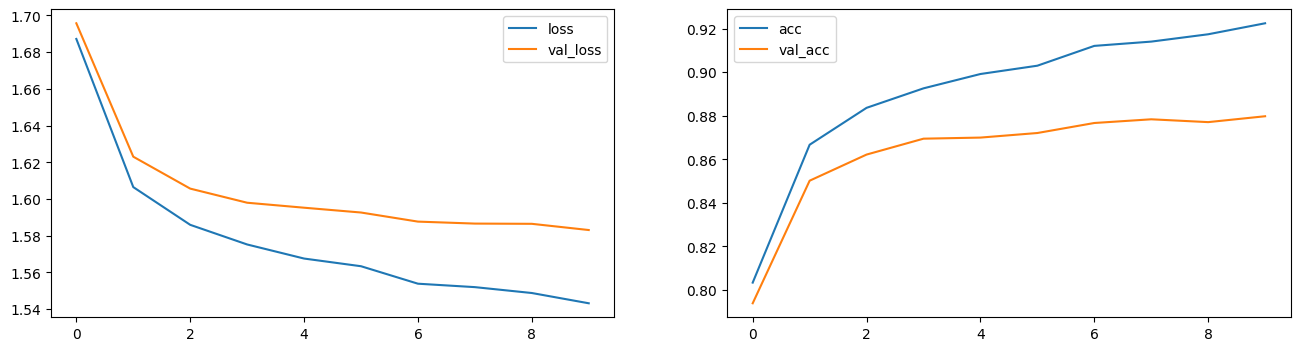

In [108]:
vis_history(acc_train_all, loss_train_all, acc_test_all, loss_test_all)

<a id="4"></a>
# 4. Полезные ссылки
- [Курс "Deep learning на пальцах", лекция 4](https://youtu.be/tnrbx7V9RbA)
- [Статья: Методы оптимизации нейронных сетей](https://habr.com/ru/post/318970/)
- YSDA [Practical RL course week04 materials](https://github.com/yandexdataschool/Practical_RL/tree/master/week04_%5Brecap%5D_deep_learning).
- PyTorch official tutorials and [this kaggle kernel](https://www.kaggle.com/pinocookie/pytorch-dataset-and-dataloader)
- PyTorch tutorial by [Stanford CS 231n course](http://cs231n.stanford.edu)

Полезные ссылки 2.0:
- [Инициализация весов](https://machinelearningmastery.com/weight-initialization-for-deep-learning-neural-networks/)
- [Почему инициализация весов нулями плохая идея?](https://habr.com/ru/articles/592711/)
- [Тонкости обучения нейронных сетей](https://education.yandex.ru/handbook/ml/article/tonkosti-obucheniya#inicializiruem-pravilno): инициализация, оптимизация, регуляризация
- [Подробнее про оптимизацию](https://education.yandex.ru/handbook/ml/article/optimizaciya-v-ml)